## IMPORTS

In [218]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split


## DEFINITION OF VARIABLES

In [254]:
# ---- Data paths ----
SOURCE_POLYMER_FILE = 'all_spectra.csv'
SOURCE_MICROPLASTIC_FILE = 'ambient_spectra.csv'

# ---- Data splitting ----
TEST_SIZE = 0.2
VAL_SPLIT = 0.2
RANDOM_STATE = 42

# ---- PCA ----
PCA_VARIANCE = 0.80          # fraction of variance to retain

# ---- Model architecture ----
N_LAYERS = 4
HIDDEN_DIM = 32
N_BINS = 4
TAIL_BOUND_MARGIN = 1.2       # multiply max |value| by this to get tail_bound
DROPOUT = 0.4

# ---- Training ----
N_EPOCHS = 150
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
CLIP_GRAD_NORM = 3.0
PATIENCE = 20

# ---- Anomaly detection ----
THRESHOLD_PERCENTILE = 10     # percentile of training log-probs for threshold

## Affine Coupling Layer

In [255]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# =============================================================================
# Rational Quadratic Spline helpers (Neural Spline Flows, Durkan et al. 2019)
# =============================================================================

def rational_quadratic_spline_forward(x, widths, heights, derivatives, tail_bound=5.0):
    """
    Apply a rational-quadratic spline transform element-wise.
    x:           (batch, dim)  inputs in [-tail_bound, tail_bound]
    widths:      (batch, dim, K)  unnormalized bin widths
    heights:     (batch, dim, K)  unnormalized bin heights
    derivatives: (batch, dim, K+1) unnormalized knot derivatives
    Returns y, log_det_jacobian  (both shape (batch, dim))
    """
    K = widths.shape[-1]

    # --- softmax widths/heights so they tile [-B, B], softplus derivatives > 0 ---
    widths = F.softmax(widths, dim=-1) * 2 * tail_bound       # (batch, dim, K)
    heights = F.softmax(heights, dim=-1) * 2 * tail_bound     # (batch, dim, K)
    derivatives = F.softplus(derivatives)                       # (batch, dim, K+1)

    # Cumulative widths/heights → bin edges
    cumwidths = torch.cumsum(widths, dim=-1)                    # (batch, dim, K)
    cumwidths = F.pad(cumwidths, (1, 0), value=0.0)             # (batch, dim, K+1)
    cumwidths = cumwidths - tail_bound                          # shift to [-B, B]

    cumheights = torch.cumsum(heights, dim=-1)
    cumheights = F.pad(cumheights, (1, 0), value=0.0)
    cumheights = cumheights - tail_bound

    # Clamp inputs to the spline domain; outside → identity
    x_clamped = x.clamp(-tail_bound + 1e-6, tail_bound - 1e-6)

    # Find which bin each x falls into
    bin_idx = torch.searchsorted(cumwidths[..., 1:], x_clamped.unsqueeze(-1)).squeeze(-1)
    bin_idx = bin_idx.clamp(0, K - 1)

    # Gather per-bin parameters
    idx = bin_idx.unsqueeze(-1)  # (batch, dim, 1)
    w_k = widths.gather(-1, idx).squeeze(-1)          # bin width
    h_k = heights.gather(-1, idx).squeeze(-1)         # bin height
    d_k = derivatives.gather(-1, idx).squeeze(-1)     # left derivative
    d_k1 = derivatives.gather(-1, idx + 1).squeeze(-1) # right derivative
    cw_k = cumwidths.gather(-1, idx).squeeze(-1)      # left edge x
    ch_k = cumheights.gather(-1, idx).squeeze(-1)     # left edge y

    s_k = h_k / w_k  # slope of bin

    # Normalized position within the bin  ξ ∈ [0, 1]
    xi = (x_clamped - cw_k) / w_k
    xi = xi.clamp(1e-6, 1.0 - 1e-6)

    # Rational quadratic formula (Eq. 4 in the paper)
    numerator = h_k * (s_k * xi * xi + d_k * xi * (1 - xi))
    denominator = s_k + (d_k + d_k1 - 2 * s_k) * xi * (1 - xi)
    y = ch_k + numerator / denominator

    # Log-derivative (Eq. 5)
    deriv_numerator = s_k * s_k * (d_k1 * xi * xi + 2 * s_k * xi * (1 - xi) + d_k * (1 - xi) ** 2)
    log_det = torch.log(deriv_numerator + 1e-8) - 2 * torch.log(denominator.abs() + 1e-8)

    return y, log_det


def rational_quadratic_spline_inverse(y, widths, heights, derivatives, tail_bound=5.0):
    """
    Inverse of the rational-quadratic spline (bisection search).
    """
    K = widths.shape[-1]

    widths = F.softmax(widths, dim=-1) * 2 * tail_bound
    heights = F.softmax(heights, dim=-1) * 2 * tail_bound
    derivatives = F.softplus(derivatives)

    cumwidths = torch.cumsum(widths, dim=-1)
    cumwidths = F.pad(cumwidths, (1, 0), value=0.0) - tail_bound

    cumheights = torch.cumsum(heights, dim=-1)
    cumheights = F.pad(cumheights, (1, 0), value=0.0) - tail_bound

    y_clamped = y.clamp(-tail_bound + 1e-6, tail_bound - 1e-6)

    bin_idx = torch.searchsorted(cumheights[..., 1:], y_clamped.unsqueeze(-1)).squeeze(-1)
    bin_idx = bin_idx.clamp(0, K - 1)

    idx = bin_idx.unsqueeze(-1)
    w_k = widths.gather(-1, idx).squeeze(-1)
    h_k = heights.gather(-1, idx).squeeze(-1)
    d_k = derivatives.gather(-1, idx).squeeze(-1)
    d_k1 = derivatives.gather(-1, idx + 1).squeeze(-1)
    cw_k = cumwidths.gather(-1, idx).squeeze(-1)
    ch_k = cumheights.gather(-1, idx).squeeze(-1)

    s_k = h_k / w_k

    # Solve quadratic for xi given y (Appendix A of the paper)
    a = h_k * (s_k - d_k) + (y_clamped - ch_k) * (d_k + d_k1 - 2 * s_k)
    b = h_k * d_k - (y_clamped - ch_k) * (d_k + d_k1 - 2 * s_k)
    c = -s_k * (y_clamped - ch_k)

    discriminant = b * b - 4 * a * c
    discriminant = discriminant.clamp(min=0)
    xi = (2 * c) / (-b - torch.sqrt(discriminant + 1e-8))
    xi = xi.clamp(1e-6, 1.0 - 1e-6)

    x = cw_k + xi * w_k
    return x


# =============================================================================
# 1D Convolutional Spline Coupling Layer
# =============================================================================

class SplineParamNet(nn.Module):
    """1D CNN with residual connections that predicts spline parameters
    from the conditioning half.

    Treats the conditioning dimensions as a 1D signal (e.g. ordered PCA
    components) and uses 1D convolutions to capture local structure between
    neighboring dimensions before projecting to spline parameters.
    """
    def __init__(self, in_dim, transform_dim, hidden_dim=128, n_bins=8, dropout=0.4):
        super().__init__()
        self.transform_dim = transform_dim
        self.n_bins = n_bins
        # Output: K widths + K heights + (K+1) derivatives per transformed dimension
        out_dim = transform_dim * (3 * n_bins + 1)

        # Lift 1-channel input to hidden_dim channels
        self.input_conv = nn.Conv1d(1, hidden_dim, kernel_size=3, padding=1)

        # Residual 1D-conv blocks (mirrors the original residual MLP blocks)
        self.block1 = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Flatten conv feature map and project to spline parameters
        self.output_proj = nn.Linear(hidden_dim * in_dim, out_dim)

        # Initialize near zero → spline starts close to identity
        nn.init.zeros_(self.output_proj.weight)
        nn.init.zeros_(self.output_proj.bias)

    def forward(self, x):
        batch = x.shape[0]
        # (batch, in_dim) → (batch, 1, in_dim) for Conv1d
        h = x.unsqueeze(1)
        h = F.relu(self.input_conv(h))      # (batch, hidden_dim, in_dim)
        h = h + self.block1(h)               # residual connection
        h = h + self.block2(h)               # residual connection
        h = h.flatten(1)                     # (batch, hidden_dim * in_dim)
        params = self.output_proj(h)
        params = params.view(batch, self.transform_dim, 3 * self.n_bins + 1)
        widths = params[:, :, :self.n_bins]
        heights = params[:, :, self.n_bins:2*self.n_bins]
        derivatives = params[:, :, 2*self.n_bins:]
        return widths, heights, derivatives


class CouplingLayer(nn.Module):
    def __init__(self, dim, hidden_dim=128, n_bins=8, tail_bound=5.0, reverse=False):
        super().__init__()
        self.dim = dim
        self.reverse = reverse
        self.split_dim = (dim + 1) // 2
        self.transform_dim = dim - self.split_dim
        self.tail_bound = tail_bound

        # When reversed, swap which half conditions and which gets transformed
        cond_dim = self.transform_dim if reverse else self.split_dim
        trans_dim = self.split_dim if reverse else self.transform_dim

        self.param_net = SplineParamNet(
            in_dim=cond_dim,
            transform_dim=trans_dim,
            hidden_dim=hidden_dim,
            n_bins=n_bins
        )

    def forward(self, x):
        if self.reverse:
            # Second half conditions, first half gets transformed
            x_cond = x[:, self.split_dim:]
            x_trans = x[:, :self.split_dim]
        else:
            # First half conditions, second half gets transformed
            x_cond = x[:, :self.split_dim]
            x_trans = x[:, self.split_dim:]

        widths, heights, derivatives = self.param_net(x_cond)
        y_trans, log_det = rational_quadratic_spline_forward(
            x_trans, widths, heights, derivatives, self.tail_bound
        )
        log_det_sum = log_det.sum(dim=1)

        if self.reverse:
            return torch.cat([y_trans, x_cond], dim=1), log_det_sum
        else:
            return torch.cat([x_cond, y_trans], dim=1), log_det_sum

    def inverse(self, y):
        if self.reverse:
            y_trans = y[:, :self.split_dim]
            y_cond = y[:, self.split_dim:]
        else:
            y_cond = y[:, :self.split_dim]
            y_trans = y[:, self.split_dim:]

        widths, heights, derivatives = self.param_net(y_cond)
        x_trans = rational_quadratic_spline_inverse(
            y_trans, widths, heights, derivatives, self.tail_bound
        )

        if self.reverse:
            return torch.cat([x_trans, y_cond], dim=1)
        else:
            return torch.cat([y_cond, x_trans], dim=1)

In [256]:
class StandardGaussian:
    def __init__(self, dim):
        self.dim = dim
        self._log_norm = -0.5 * dim * np.log(2.0 * np.pi)

    def log_prob(self, z):
        return self._log_norm - 0.5 * (z * z).sum(dim=1)
    
    def sample(self, n_samples):
        return torch.randn(n_samples, self.dim)

In [257]:
class PermutationLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.register_buffer('permutation', torch.randperm(dim))
        self.register_buffer('inverse_permutation', torch.argsort(self.permutation))

    def forward(self, x):
        return x[:, self.permutation], torch.zeros(x.shape[0], device=x.device)
    
    def inverse(self, y):
        return y[:,self.inverse_permutation]
    

In [258]:
class ActNorm(nn.Module):
    """
    Activation Normalization (Kingma & Dhariwal, 2018 — Glow).
    Learned per-channel scale and bias with data-dependent initialization.
    On the first forward pass the parameters are set so that the output of
    the layer has zero mean and unit variance (per dimension).
    """
    def __init__(self, dim):
        super().__init__()
        self.log_scale = nn.Parameter(torch.zeros(1, dim))
        self.bias = nn.Parameter(torch.zeros(1, dim))
        self.register_buffer('initialized', torch.tensor(False))

    @torch.no_grad()
    def _data_dependent_init(self, x):
        """Initialize so that output has mean=0, std=1."""
        mean = x.mean(dim=0, keepdim=True)
        std = x.std(dim=0, keepdim=True) + 1e-6
        self.bias.data.copy_(-mean)
        self.log_scale.data.copy_(-torch.log(std))
        self.initialized.fill_(True)

    def forward(self, x):
        if not self.initialized:
            self._data_dependent_init(x)
        z = (x + self.bias) * torch.exp(self.log_scale)
        # log |det J| = sum of log_scale (same for every sample)
        log_det = self.log_scale.sum().expand(x.shape[0])
        return z, log_det

    def inverse(self, z):
        x = z * torch.exp(-self.log_scale) - self.bias
        return x


class BatchNormFlow(nn.Module):
    """Batch normalization as a flow layer (with tractable log-det)."""
    def __init__(self, dim, momentum=0.1, eps=1e-5):
        super().__init__()
        self.dim = dim
        self.eps = eps
        self.momentum = momentum
        self.log_gamma = nn.Parameter(torch.zeros(1, dim))
        self.beta = nn.Parameter(torch.zeros(1, dim))
        self.register_buffer('running_mean', torch.zeros(1, dim))
        self.register_buffer('running_var', torch.ones(1, dim))

    def forward(self, x):
        if self.training:
            mean = x.mean(dim=0, keepdim=True)
            var = x.var(dim=0, keepdim=True) + self.eps
            self.running_mean.mul_(1 - self.momentum).add_(mean * self.momentum)
            self.running_var.mul_(1 - self.momentum).add_(var * self.momentum)
        else:
            mean = self.running_mean
            var = self.running_var + self.eps

        x_hat = (x - mean) / torch.sqrt(var)
        z = x_hat * torch.exp(self.log_gamma) + self.beta
        log_det = (self.log_gamma - 0.5 * torch.log(var)).sum().expand(x.shape[0])
        return z, log_det

    def inverse(self, z):
        mean = self.running_mean
        var = self.running_var + self.eps
        x_hat = (z - self.beta) * torch.exp(-self.log_gamma)
        x = x_hat * torch.sqrt(var) + mean
        return x

In [259]:
class NormalizingFlow(nn.Module):
    def __init__(self, dim, n_layers = 4, hidden_dim = 128, n_bins = 8, tail_bound = 3.0):
        super().__init__()
        self.dim = dim
        self.n_layers = n_layers
        self.base_dist = StandardGaussian(dim)
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            # ActNorm + BatchNormFlow before each coupling layer
            self.layers.append(ActNorm(dim))
            self.layers.append(BatchNormFlow(dim))
            # Alternate which half gets transformed each layer
            self.layers.append(CouplingLayer(
                dim, hidden_dim=hidden_dim, n_bins=n_bins,
                tail_bound=tail_bound, reverse=(i % 2 == 1)
            ))
            if i < n_layers - 1:
                self.layers.append(PermutationLayer(dim))

    def forward(self, x):

        z = x
        log_det_sum = torch.zeros(x.shape[0], device=x.device)

        for layer in self.layers:
            z, log_det = layer(z)
            log_det_sum += log_det

        log_prob_z = self.base_dist.log_prob(z)
        log_prob_x = log_prob_z + log_det_sum

        return log_prob_x
    
    def inverse(self, z):
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x
    
    def sample(self, n_samples):
        z = self.base_dist.sample(n_samples)
        x = self.inverse(z)

        return x

In [260]:
def train_flow(model, data, n_epochs=100, batch_size=32, lr=1e-3,
               weight_decay=1e-5, clip_grad_norm=5.0, val_data=None,
               patience=15):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr * 0.01)

    n_batches = len(data) // batch_size
    losses = []
    val_losses = []

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in tqdm(range(n_epochs)):
        model.train()
        perm = torch.randperm(len(data))
        data_shuffled = data[perm]

        epoch_loss = 0

        for i in range(n_batches):
            batch = data_shuffled[i*batch_size:(i+1)*batch_size]
            
            optimizer.zero_grad()

            log_prob = model(batch)
            loss = -log_prob.mean()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
            optimizer.step()

            epoch_loss += loss.item()
        
        scheduler.step()
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)

        # Validation loss (for monitoring overfitting)
        if val_data is not None:
            model.eval()
            with torch.no_grad():
                val_log_prob = model(val_data)
                val_loss = -val_log_prob.mean().item()
            val_losses.append(val_loss)

            # Early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= patience:
                print(f'\nEarly stopping at epoch {epoch+1} (no val improvement for {patience} epochs)')
                break

        if (epoch + 1) % 10 == 0:
            msg = f'Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}'
            if val_data is not None:
                msg += f', Val Loss: {val_losses[-1]:.4f}'
            msg += f', LR: {scheduler.get_last_lr()[0]:.6f}'
            print(msg)

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f'Restored best model (val loss: {best_val_loss:.4f})')

    return losses, val_losses

## Training

In [261]:
# Load data
df_polymer = pd.read_csv(SOURCE_POLYMER_FILE, index_col=0)
df_amb = pd.read_csv(SOURCE_MICROPLASTIC_FILE, index_col=0)
# Dropping singular samples from the polymer dataset to ensure stratified splitting works correctly
df_polymer = df_polymer[df_polymer['polymer'].map(df_polymer['polymer'].value_counts()) > 1]
df_train, df_polymer_test = train_test_split(df_polymer, test_size=TEST_SIZE, stratify=df_polymer['polymer'], random_state=RANDOM_STATE)
df_test = pd.concat([df_polymer_test, df_amb], ignore_index=True)
feature_cols = [
    col for col in df_train.columns
    if col != 'polymer' and str(col) != '' and not str(col).startswith('Unnamed')
]
print(f"Training data (normal polymers): {df_train.shape[0]} samples")
print(f"Test data (abnormal microplastics): {df_test.shape[0]} samples")

Training data (normal polymers): 970 samples
Test data (abnormal microplastics): 298 samples


In [262]:
# Prepare training data (normal)
normal_data = df_train[feature_cols].values

# ALTERNATIVE: Use RobustScaler if values are too extreme
scaler = StandardScaler()
normal_scaled = scaler.fit_transform(normal_data)

# PCA dimensionality reduction (no post-PCA scaling — preserve variance ordering)
pca = PCA(n_components=PCA_VARIANCE, svd_solver='full')
normal_reduced = pca.fit_transform(normal_scaled)
n_components = pca.n_components_
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Compute tail_bound from data so the spline domain covers every PCA dimension
TAIL_BOUND = float(np.abs(normal_reduced).max()) * TAIL_BOUND_MARGIN

print(f"PCA: keeping {n_components} / {normal_scaled.shape[1]} components "
      f"({cumulative_variance[-1]*100:.1f}% variance retained)")
print(f"PC stds — PC0: {normal_reduced[:, 0].std():.2f}, "
      f"PC{n_components-1}: {normal_reduced[:, -1].std():.2f}")
print(f"Tail bound (auto): ±{TAIL_BOUND:.2f}  (max |value| × {TAIL_BOUND_MARGIN})")

# ---- Train / Validation split ----
n_val = int(len(normal_reduced) * VAL_SPLIT)
perm = np.random.RandomState(RANDOM_STATE).permutation(len(normal_reduced))
val_idx, train_idx = perm[:n_val], perm[n_val:]

train_tensor = torch.FloatTensor(normal_reduced[train_idx])
val_tensor   = torch.FloatTensor(normal_reduced[val_idx])

print(f"Train split: {len(train_tensor)} samples, Val split: {len(val_tensor)} samples")

# Initialize and train model
n_features = train_tensor.shape[1]
model = NormalizingFlow(
    dim=n_features, n_layers=N_LAYERS, hidden_dim=HIDDEN_DIM,
    n_bins=N_BINS, tail_bound=TAIL_BOUND
)

print(f"\nTraining Normalizing Flow model (WITH STANDARD SCALER + PCA)...")
print(f"Reduced from {normal_scaled.shape[1]} → {n_features} features")
print(f"Feature 0 range: [{normal_data[:, 0].min():.2f}, {normal_data[:, 0].max():.2f}]")

losses, val_losses = train_flow(
    model, train_tensor, n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY, clip_grad_norm=CLIP_GRAD_NORM, val_data=val_tensor,
    patience=PATIENCE
)

PCA: keeping 17 / 535 components (80.0% variance retained)
PC stds — PC0: 10.70, PC16: 1.92
Tail bound (auto): ±35.60  (max |value| × 1.2)
Train split: 776 samples, Val split: 194 samples

Training Normalizing Flow model (WITH STANDARD SCALER + PCA)...
Reduced from 535 → 17 features
Feature 0 range: [-3.05, 2.89]


  7%|▋         | 10/150 [00:04<01:07,  2.07it/s]

Epoch 10/150, Loss: 40.1263, Val Loss: 41.0766, LR: 0.000099


 13%|█▎        | 20/150 [00:09<01:03,  2.06it/s]

Epoch 20/150, Loss: 38.3165, Val Loss: 40.4002, LR: 0.000096


...

Epoch 130/150, Loss: 33.2137, Val Loss: 35.6824, LR: 0.000005


 93%|█████████▎| 140/150 [01:07<00:04,  2.13it/s]

Epoch 140/150, Loss: 33.0500, Val Loss: 35.7326, LR: 0.000002


100%|██████████| 150/150 [01:11<00:00,  2.09it/s]

Epoch 150/150, Loss: 32.6834, Val Loss: 35.7535, LR: 0.000001
Restored best model (val loss: 35.6613)


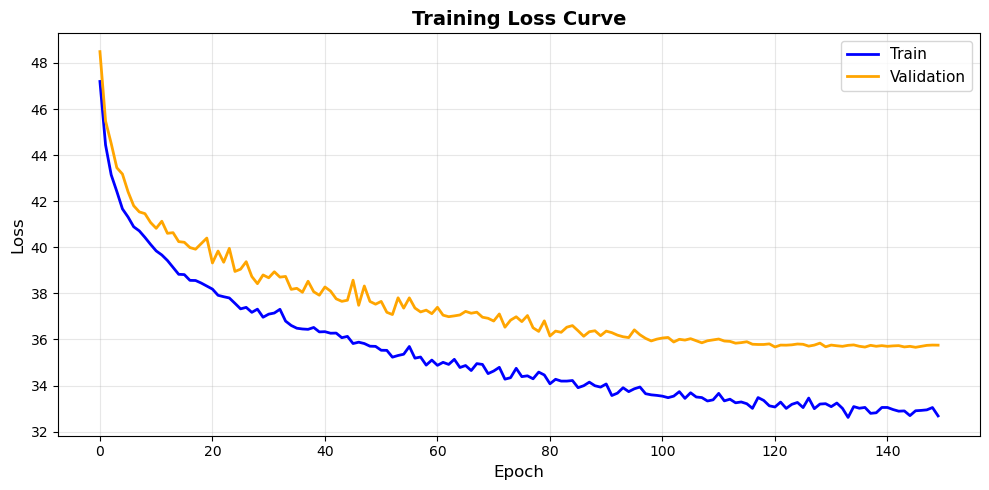

Final train loss: 32.6834
Final val loss:   35.7535
Train-Val gap:    3.0700  ✓ looks OK
Loss change (first to last epoch): 14.5107
✓ Loss is decreasing - training appears stable


In [263]:
# Plot training loss to diagnose convergence
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses, linewidth=2, color='blue', label='Train')
if val_losses:
    ax.plot(val_losses, linewidth=2, color='orange', label='Validation')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {losses[-1]:.4f}")
if val_losses:
    print(f"Final val loss:   {val_losses[-1]:.4f}")
    gap = val_losses[-1] - losses[-1]
    print(f"Train-Val gap:    {gap:.4f}  {'⚠️  overfitting' if gap > 5 else '✓ looks OK'}")
print(f"Loss change (first to last epoch): {losses[0] - losses[-1]:.4f}")
if losses[-1] > losses[-10]:
    print("⚠️  WARNING: Loss is increasing in recent epochs - model may not be converging well")
else:
    print("✓ Loss is decreasing - training appears stable")

ANOMALY DETECTION: Training Data Statistics
Training samples: 776
Mean log probability: -31.2787
Std log probability: 8.1530
Threshold (10th percentile): -42.7788
Threshold (anomaly score): 42.7788

CLASSIFYING TEST DATA

Total test samples: 298
  - Normal polymer samples (expected NORMAL): 243
  - Ambient microplastic samples (expected ANOMALY): 55

Predicted as ANOMALY: 113 (37.9%)
Predicted as NORMAL: 185 (62.1%)

CLASSIFICATION METRICS

Precision: 0.4159  (of predicted anomalies, how many are truly anomalous)
Recall:    0.8545  (of actual anomalies, how many were detected)
F1 Score:  0.5595

Full Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.73      0.83       243
     ANOMALY       0.42      0.85      0.56        55

    accuracy                           0.75       298
   macro avg       0.69      0.79      0.69       298
weighted avg       0.86      0.75      0.78       298

Confusion Matrix:
                  Predic

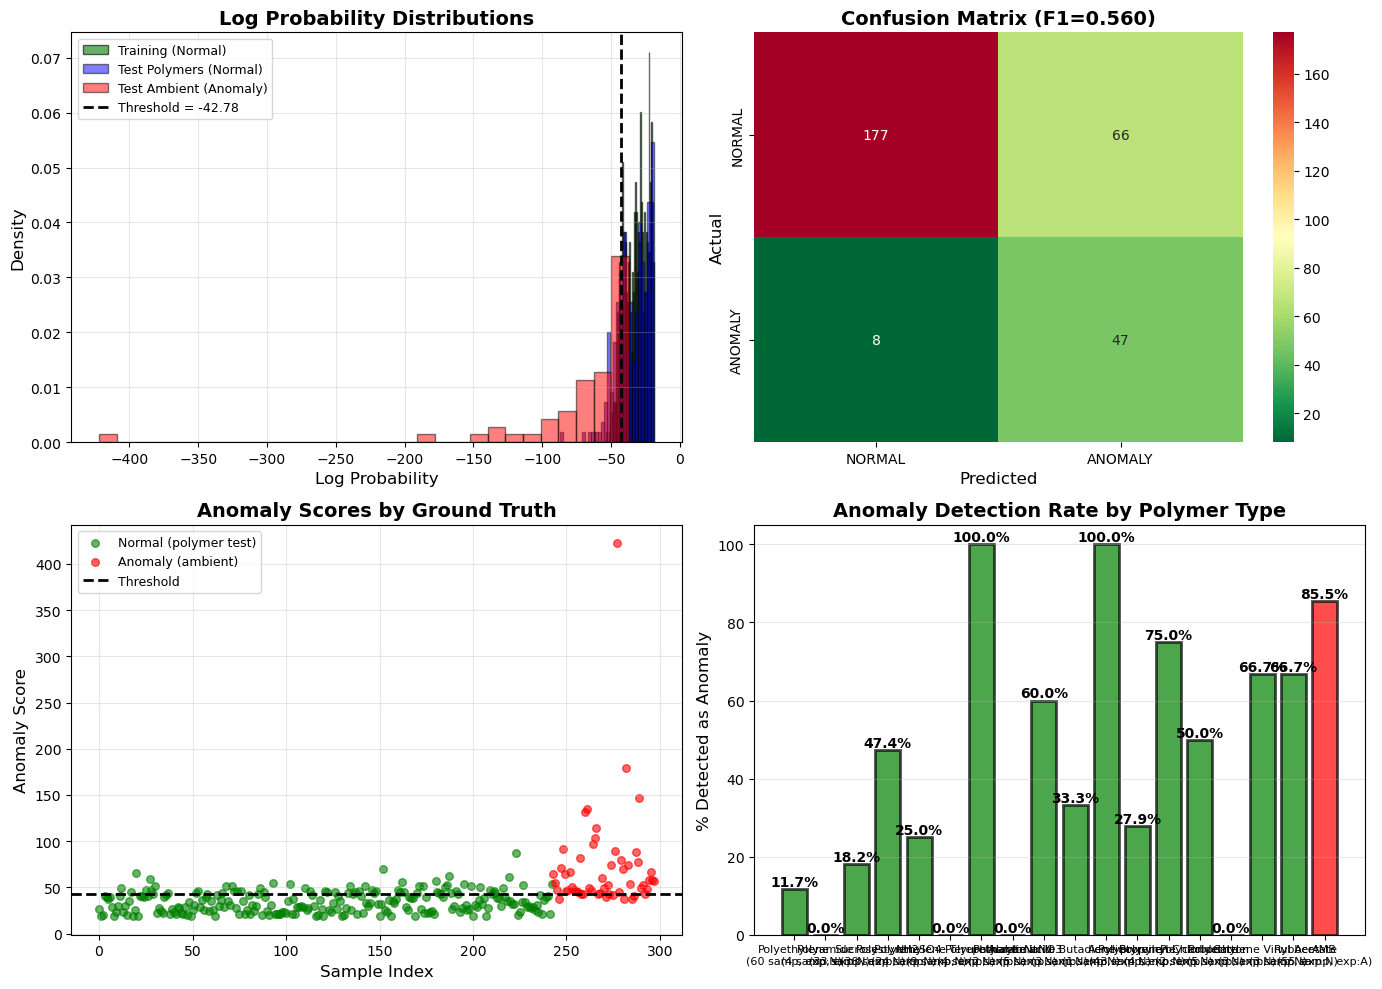


Results saved to: anomaly_detection_results.csv


In [264]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

# ============================================================================
# EVALUATION: Classify test data as anomaly or normal
# Test set contains:
#   - df_polymer_test samples (NORMAL - known polymers held out from training)
#   - df_amb samples (ANOMALY - ambient microplastics)
# ============================================================================

model.eval()

# Step 1: Score TRAINING data to compute threshold
with torch.no_grad():
    train_log_probs = model(train_tensor).cpu().numpy()

# Compute threshold from training data statistics
train_mean = train_log_probs.mean()
train_std = train_log_probs.std()
threshold_log_prob = np.percentile(train_log_probs, THRESHOLD_PERCENTILE)
threshold_anomaly_score = -threshold_log_prob

print(f"{'='*70}")
print(f"ANOMALY DETECTION: Training Data Statistics")
print(f"{'='*70}")
print(f"Training samples: {len(train_log_probs)}")
print(f"Mean log probability: {train_mean:.4f}")
print(f"Std log probability: {train_std:.4f}")
print(f"Threshold ({THRESHOLD_PERCENTILE}th percentile): {threshold_log_prob:.4f}")
print(f"Threshold (anomaly score): {threshold_anomaly_score:.4f}")

# Step 2: Score TEST data
print(f"\n{'='*70}")
print(f"CLASSIFYING TEST DATA")
print(f"{'='*70}\n")

with torch.no_grad():
    test_data = df_test[feature_cols].values
    if scaler is not None:
        test_scaled = scaler.transform(test_data)
    else:
        test_scaled = test_data.astype(np.float32)
    # Apply the same PCA projection used during training
    test_reduced = pca.transform(test_scaled)
    test_tensor = torch.FloatTensor(test_reduced)
    test_log_probs = model(test_tensor).cpu().numpy()

test_anomaly_scores = -test_log_probs
test_predictions = (test_anomaly_scores >= threshold_anomaly_score).astype(int)

# Step 3: Create ground truth labels
# Polymer test samples are NORMAL (0), ambient samples are ANOMALY (1)
n_polymer_test = len(df_polymer_test)
n_amb = len(df_amb)
ground_truth = np.array([0] * n_polymer_test + [1] * n_amb)

# Step 4: Create results dataframe
results_df = pd.DataFrame({
    'Sample_Index': range(len(test_log_probs)),
    'Log_Probability': test_log_probs.flatten(),
    'Anomaly_Score': test_anomaly_scores.flatten(),
    'Ground_Truth': ground_truth,
    'Predicted': test_predictions,
    'Ground_Truth_Label': ['ANOMALY' if g == 1 else 'NORMAL' for g in ground_truth],
    'Predicted_Label': ['ANOMALY' if p == 1 else 'NORMAL' for p in test_predictions]
})

if 'polymer' in df_test.columns:
    results_df['Polymer_Type'] = df_test['polymer'].values

# Display summary
anomaly_count = test_predictions.sum()
normal_count = len(test_predictions) - anomaly_count

print(f"Total test samples: {len(test_predictions)}")
print(f"  - Normal polymer samples (expected NORMAL): {n_polymer_test}")
print(f"  - Ambient microplastic samples (expected ANOMALY): {n_amb}")
print(f"\nPredicted as ANOMALY: {anomaly_count} ({100*anomaly_count/len(test_predictions):.1f}%)")
print(f"Predicted as NORMAL: {normal_count} ({100*normal_count/len(test_predictions):.1f}%)")

# Step 5: Compute proper metrics
print(f"\n{'='*70}")
print(f"CLASSIFICATION METRICS")
print(f"{'='*70}\n")

precision = precision_score(ground_truth, test_predictions, zero_division=0)
recall = recall_score(ground_truth, test_predictions, zero_division=0)
f1 = f1_score(ground_truth, test_predictions, zero_division=0)

print(f"Precision: {precision:.4f}  (of predicted anomalies, how many are truly anomalous)")
print(f"Recall:    {recall:.4f}  (of actual anomalies, how many were detected)")
print(f"F1 Score:  {f1:.4f}")

print(f"\nFull Classification Report:")
print(classification_report(ground_truth, test_predictions, target_names=['NORMAL', 'ANOMALY']))

cm = confusion_matrix(ground_truth, test_predictions)
print(f"Confusion Matrix:")
print(f"                  Predicted NORMAL  Predicted ANOMALY")
print(f"  Actual NORMAL   {cm[0,0]:>16}  {cm[0,1]:>17}")
print(f"  Actual ANOMALY  {cm[1,0]:>16}  {cm[1,1]:>17}")

# Step 6: Per-sample results
print(f"\n{'='*70}")
print(f"PER-SAMPLE RESULTS (first 20 samples)")
print(f"{'='*70}\n")
print(results_df.head(20).to_string(index=False))

if len(results_df) > 20:
    print(f"\n... and {len(results_df) - 20} more samples")

# Step 7: Per-polymer breakdown
if 'polymer' in df_test.columns:
    print(f"\n{'='*70}")
    print(f"RESULTS BY POLYMER TYPE")
    print(f"{'='*70}")
    
    for polymer in df_test['polymer'].unique():
        polymer_mask = results_df['Polymer_Type'] == polymer
        polymer_results = results_df[polymer_mask]
        
        anomaly_detected = polymer_results['Predicted'].sum()
        total = len(polymer_results)
        pct = 100 * anomaly_detected / total
        avg_anomaly_score = polymer_results['Anomaly_Score'].mean()
        expected = 'ANOMALY' if polymer_results['Ground_Truth'].iloc[0] == 1 else 'NORMAL'
        
        print(f"\n{polymer} (expected: {expected}):")
        print(f"  Total samples: {total}")
        print(f"  Detected as ANOMALY: {anomaly_detected}/{total} ({pct:.1f}%)")
        print(f"  Avg anomaly score: {avg_anomaly_score:.4f}")

# Step 8: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Histogram of log probabilities
ax = axes[0, 0]
ax.hist(train_log_probs, bins=50, alpha=0.6, label='Training (Normal)', 
        color='green', edgecolor='black', density=True)
# Separate test into polymer_test (normal) and ambient (anomaly)
polymer_test_log_probs = test_log_probs[:n_polymer_test]
amb_log_probs = test_log_probs[n_polymer_test:]
ax.hist(polymer_test_log_probs, bins=30, alpha=0.5, label='Test Polymers (Normal)', 
        color='blue', edgecolor='black', density=True)
ax.hist(amb_log_probs, bins=30, alpha=0.5, label='Test Ambient (Anomaly)', 
        color='red', edgecolor='black', density=True)
ax.axvline(threshold_log_prob, color='black', linestyle='--', linewidth=2, 
          label=f'Threshold = {threshold_log_prob:.2f}')
ax.set_xlabel('Log Probability', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Log Probability Distributions', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Plot 2: Confusion matrix heatmap
ax = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', 
            xticklabels=['NORMAL', 'ANOMALY'], yticklabels=['NORMAL', 'ANOMALY'], ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix (F1={f1:.3f})', fontsize=14, fontweight='bold')

# Plot 3: Anomaly scores scatter plot colored by ground truth
ax = axes[1, 0]
normal_mask = ground_truth == 0
anomaly_mask = ground_truth == 1
ax.scatter(np.where(normal_mask)[0], test_anomaly_scores[normal_mask], 
           c='green', alpha=0.6, s=30, label='Normal (polymer test)')
ax.scatter(np.where(anomaly_mask)[0], test_anomaly_scores[anomaly_mask], 
           c='red', alpha=0.6, s=30, label='Anomaly (ambient)')
ax.axhline(threshold_anomaly_score, color='black', linestyle='--', linewidth=2, label='Threshold')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Anomaly Score', fontsize=12)
ax.set_title('Anomaly Scores by Ground Truth', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Plot 4: Detection rates by polymer type
if 'polymer' in df_test.columns:
    ax = axes[1, 1]
    polymer_types = results_df['Polymer_Type'].unique()
    detection_rates = []
    labels_by_polymer = []
    bar_colors = []
    
    for polymer in polymer_types:
        polymer_mask = results_df['Polymer_Type'] == polymer
        polymer_results = results_df[polymer_mask]
        total = len(polymer_results)
        anomaly_detected = polymer_results['Predicted'].sum()
        detection_rates.append(100 * anomaly_detected / total)
        expected = 'A' if polymer_results['Ground_Truth'].iloc[0] == 1 else 'N'
        labels_by_polymer.append(f"{polymer}\n({total} samp, exp:{expected})")
        bar_colors.append('red' if expected == 'A' else 'green')
    
    bars = ax.bar(range(len(polymer_types)), detection_rates, color=bar_colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_xticks(range(len(polymer_types)))
    ax.set_xticklabels(labels_by_polymer, fontsize=8)
    ax.set_ylabel('% Detected as Anomaly', fontsize=12)
    ax.set_title('Anomaly Detection Rate by Polymer Type', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, rate in zip(bars, detection_rates):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{rate:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
else:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Step 9: Save results to CSV
output_filename = 'anomaly_detection_results.csv'
results_df.to_csv(output_filename, index=False)

print(f"\nResults saved to: {output_filename}")

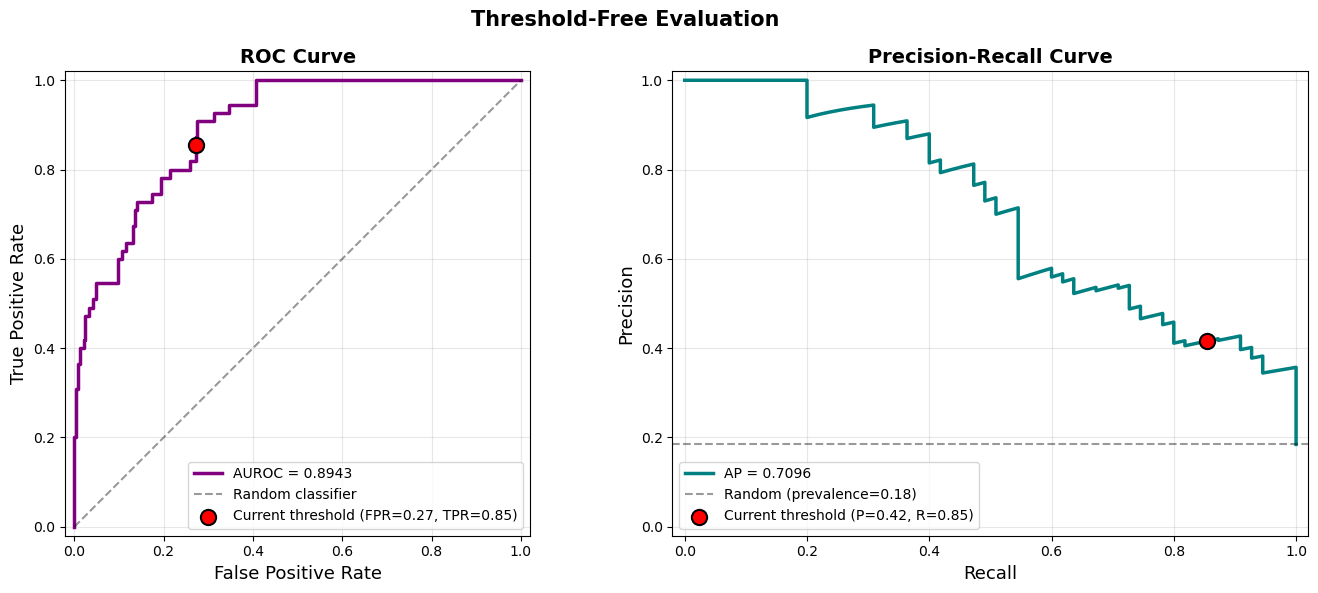

AUROC:              0.8943
Average Precision:  0.7096
Current threshold operating point:
  FPR = 0.2716, TPR = 0.8545
  Precision = 0.4159, Recall = 0.8545


In [266]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# ============================================================================
# AUROC & Precision-Recall Curves
# ============================================================================

auroc = roc_auc_score(ground_truth, test_anomaly_scores)
fpr, tpr, roc_thresholds = roc_curve(ground_truth, test_anomaly_scores)

ap = average_precision_score(ground_truth, test_anomaly_scores)
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(ground_truth, test_anomaly_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- ROC Curve ----
ax = axes[0]
ax.plot(fpr, tpr, color='purple', linewidth=2.5, label=f'AUROC = {auroc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random classifier')
# Mark the operating point from the current threshold
current_preds = (test_anomaly_scores >= threshold_anomaly_score).astype(int)
current_fpr = (current_preds[ground_truth == 0] == 1).mean()
current_tpr = (current_preds[ground_truth == 1] == 1).mean()
ax.scatter([current_fpr], [current_tpr], color='red', s=120, zorder=5, edgecolors='black',
           linewidths=1.5, label=f'Current threshold (FPR={current_fpr:.2f}, TPR={current_tpr:.2f})')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
ax.grid(alpha=0.3)

# ---- Precision-Recall Curve ----
ax = axes[1]
ax.plot(rec_curve, prec_curve, color='teal', linewidth=2.5, label=f'AP = {ap:.4f}')
baseline_prevalence = ground_truth.mean()
ax.axhline(baseline_prevalence, color='k', linestyle='--', alpha=0.4, label=f'Random (prevalence={baseline_prevalence:.2f})')
current_prec = precision_score(ground_truth, current_preds, zero_division=0)
current_rec = recall_score(ground_truth, current_preds, zero_division=0)
ax.scatter([current_rec], [current_prec], color='red', s=120, zorder=5, edgecolors='black',
           linewidths=1.5, label=f'Current threshold (P={current_prec:.2f}, R={current_rec:.2f})')
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3)

plt.suptitle('Threshold-Free Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"AUROC:              {auroc:.4f}")
print(f"Average Precision:  {ap:.4f}")
print(f"Current threshold operating point:")
print(f"  FPR = {current_fpr:.4f}, TPR = {current_tpr:.4f}")
print(f"  Precision = {current_prec:.4f}, Recall = {current_rec:.4f}")

In [250]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Compute all metrics
accuracy = accuracy_score(ground_truth, test_predictions)
precision = precision_score(ground_truth, test_predictions, zero_division=0)
recall = recall_score(ground_truth, test_predictions, zero_division=0)
f1 = f1_score(ground_truth, test_predictions, zero_division=0)
# AUROC uses continuous anomaly scores (not binary predictions)
auroc = roc_auc_score(ground_truth, test_anomaly_scores)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUROC'],
    'Value': [accuracy, precision, recall, f1, auroc]
})
metrics_df['Value'] = metrics_df['Value'].map(lambda x: f"{x:.4f}")

print(f"{'='*40}")
print(f"  CLASSIFICATION METRICS SUMMARY")
print(f"{'='*40}")
print(metrics_df.to_string(index=False))
print(f"{'='*40}")
print(f"\nThreshold: {THRESHOLD_PERCENTILE}th percentile of training log-probs")
print(f"PCA components: {n_components} ({cumulative_variance[-1]*100:.1f}% variance)")

  CLASSIFICATION METRICS SUMMARY
   Metric  Value
 Accuracy 0.7248
Precision 0.3663
   Recall 0.6727
 F1 Score 0.4744
    AUROC 0.8625

Threshold: 10th percentile of training log-probs
PCA components: 15 (78.7% variance)


## Assumption Validation Diagnostics
Check whether the key assumptions of the normalizing flow pipeline hold for this data.

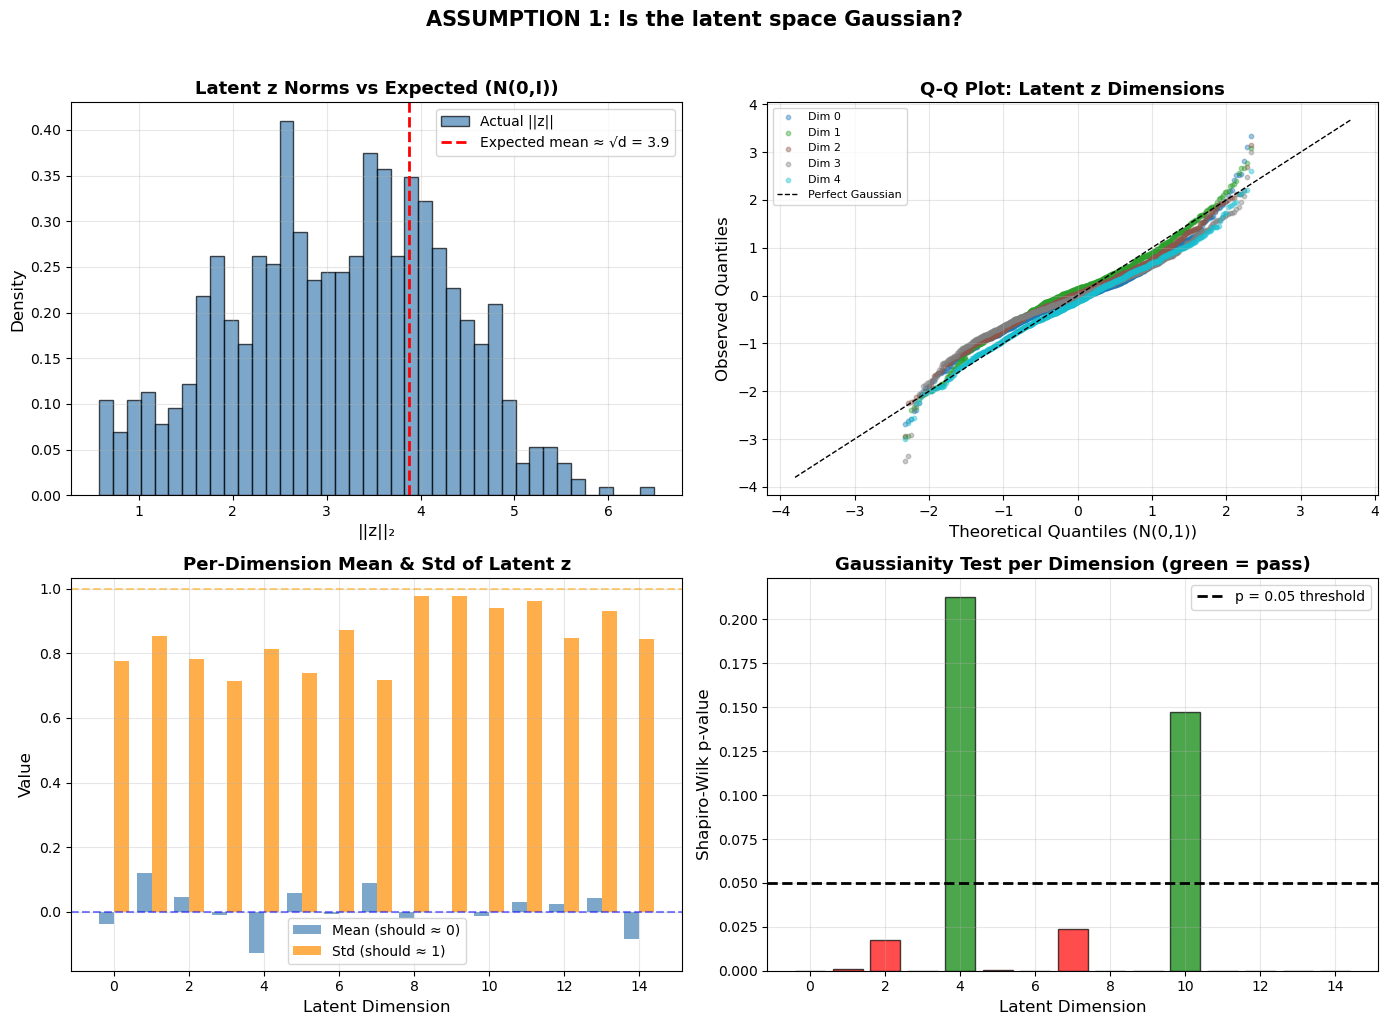


Shapiro-Wilk: 2/15 dimensions pass Gaussianity test (p > 0.05)
Latent z mean: 0.0081 (should be ≈ 0), std: 0.8498 (should be ≈ 1)


In [251]:
# =============================================================================
# ASSUMPTION 1: Gaussian base distribution — are the latent codes actually Gaussian?
# The flow maps data → z ~ N(0,I). If z isn't Gaussian, the model hasn't converged
# or the architecture is too limited.
# =============================================================================
from scipy import stats
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    # Push training data through the flow to get latent z
    z_train = train_tensor.clone()
    for layer in model.layers:
        z_train, _ = layer(z_train)
    z_train = z_train.cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Histogram of z norms vs expected chi distribution
ax = axes[0, 0]
z_norms = np.linalg.norm(z_train, axis=1)
expected_mean = np.sqrt(n_features)  # E[||z||] for z ~ N(0,I) in d dimensions
expected_std = 1.0 / np.sqrt(2)      # approximate
ax.hist(z_norms, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='black', label='Actual ||z||')
ax.axvline(expected_mean, color='red', linestyle='--', linewidth=2, label=f'Expected mean ≈ √d = {expected_mean:.1f}')
ax.set_xlabel('||z||₂', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Latent z Norms vs Expected (N(0,I))', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# (b) Q-Q plot of first few latent dimensions
ax = axes[0, 1]
n_dims_to_check = min(5, z_train.shape[1])
colors = plt.cm.tab10(np.linspace(0, 1, n_dims_to_check))
for d in range(n_dims_to_check):
    sorted_z = np.sort(z_train[:, d])
    theoretical = stats.norm.ppf(np.linspace(0.01, 0.99, len(sorted_z)))
    ax.scatter(theoretical, sorted_z, alpha=0.4, s=10, color=colors[d], label=f'Dim {d}')
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect Gaussian')
ax.set_xlabel('Theoretical Quantiles (N(0,1))', fontsize=12)
ax.set_ylabel('Observed Quantiles', fontsize=12)
ax.set_title('Q-Q Plot: Latent z Dimensions', fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (c) Per-dimension mean and std
ax = axes[1, 0]
z_means = z_train.mean(axis=0)
z_stds = z_train.std(axis=0)
dims = np.arange(z_train.shape[1])
ax.bar(dims - 0.2, z_means, width=0.4, label='Mean (should ≈ 0)', color='steelblue', alpha=0.7)
ax.bar(dims + 0.2, z_stds, width=0.4, label='Std (should ≈ 1)', color='darkorange', alpha=0.7)
ax.axhline(0, color='blue', linestyle='--', alpha=0.5)
ax.axhline(1, color='orange', linestyle='--', alpha=0.5)
ax.set_xlabel('Latent Dimension', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Per-Dimension Mean & Std of Latent z', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# (d) Shapiro-Wilk test per dimension
ax = axes[1, 1]
p_values = []
for d in range(z_train.shape[1]):
    # Shapiro-Wilk has sample limit; subsample if needed
    sample = z_train[:min(500, len(z_train)), d]
    _, p = stats.shapiro(sample)
    p_values.append(p)
ax.bar(dims, p_values, color=['green' if p > 0.05 else 'red' for p in p_values], alpha=0.7, edgecolor='black')
ax.axhline(0.05, color='black', linestyle='--', linewidth=2, label='p = 0.05 threshold')
ax.set_xlabel('Latent Dimension', fontsize=12)
ax.set_ylabel('Shapiro-Wilk p-value', fontsize=12)
ax.set_title('Gaussianity Test per Dimension (green = pass)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('ASSUMPTION 1: Is the latent space Gaussian?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

n_pass = sum(1 for p in p_values if p > 0.05)
print(f"\nShapiro-Wilk: {n_pass}/{len(p_values)} dimensions pass Gaussianity test (p > 0.05)")
print(f"Latent z mean: {z_means.mean():.4f} (should be ≈ 0), std: {z_stds.mean():.4f} (should be ≈ 1)")

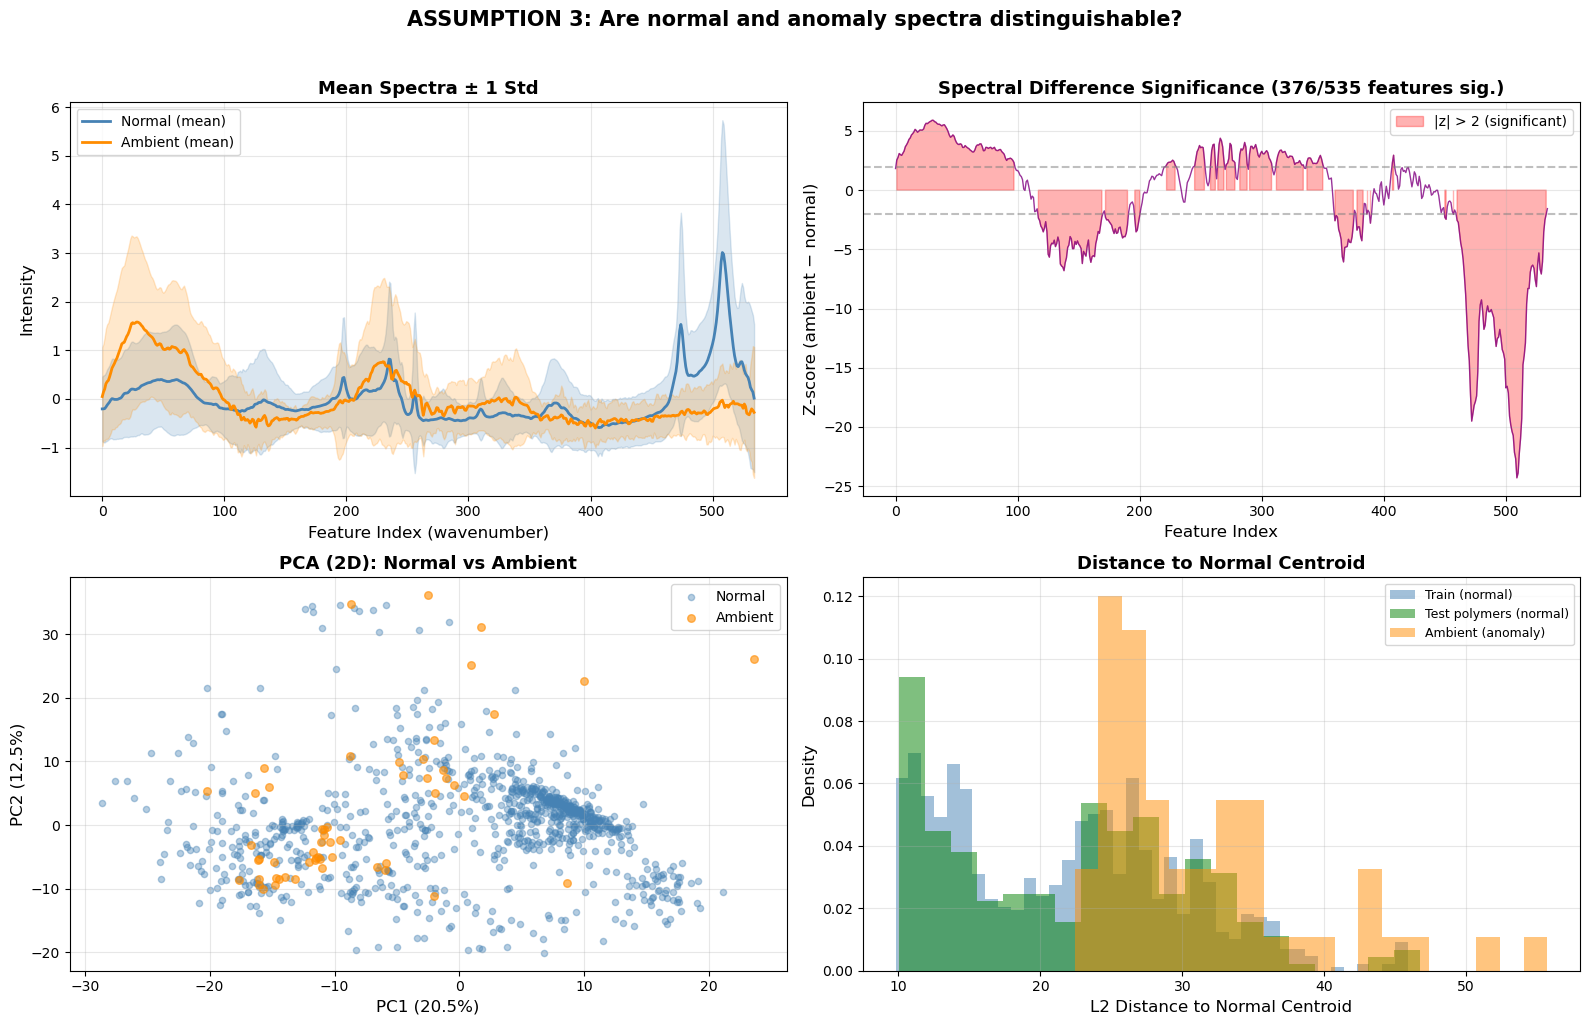


KS test (normal vs ambient centroid distances): statistic = 0.5619, p = 5.8655e-16
✓ Distributions are statistically different (p < 0.01)

Cosine similarity to normal centroid:
  Normal:  mean=0.5299, std=0.3100
  Ambient: mean=0.1436, std=0.1197
  Gap: 0.3863  ✓ meaningful gap


In [233]:
# =============================================================================
# ASSUMPTION 3: Normal vs anomaly spectra are distinguishable
# If the raw spectra overlap heavily, no model can separate them.
# =============================================================================

# Define variables needed for diagnostics (originally from Assumption 2 cell)
n_polymer_test_diag = len(df_polymer_test)
n_amb_diag = len(df_amb)
test_raw = df_test[feature_cols].values

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

train_spectra = df_train[feature_cols].values
amb_spectra = df_amb[feature_cols].values
wavenumbers = np.arange(train_spectra.shape[1])

# (a) Mean spectra comparison
ax = axes[0, 0]
train_mean = train_spectra.mean(axis=0)
train_std = train_spectra.std(axis=0)
amb_mean = amb_spectra.mean(axis=0)
amb_std = amb_spectra.std(axis=0)
ax.plot(wavenumbers, train_mean, color='steelblue', linewidth=2, label='Normal (mean)')
ax.fill_between(wavenumbers, train_mean - train_std, train_mean + train_std, alpha=0.2, color='steelblue')
ax.plot(wavenumbers, amb_mean, color='darkorange', linewidth=2, label='Ambient (mean)')
ax.fill_between(wavenumbers, amb_mean - amb_std, amb_mean + amb_std, alpha=0.2, color='darkorange')
ax.set_xlabel('Feature Index (wavenumber)', fontsize=12)
ax.set_ylabel('Intensity', fontsize=12)
ax.set_title('Mean Spectra ± 1 Std', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# (b) Difference spectrum with significance
ax = axes[0, 1]
diff = amb_mean - train_mean
combined_std = np.sqrt(train_std**2 / len(train_spectra) + amb_std**2 / len(amb_spectra))
z_score = diff / (combined_std + 1e-10)
significant = np.abs(z_score) > 2
ax.plot(wavenumbers, z_score, color='purple', linewidth=1, alpha=0.8)
ax.fill_between(wavenumbers, z_score, where=significant, color='red', alpha=0.3, label='|z| > 2 (significant)')
ax.axhline(2, color='gray', linestyle='--', alpha=0.5)
ax.axhline(-2, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Feature Index', fontsize=12)
ax.set_ylabel('Z-score (ambient − normal)', fontsize=12)
ax.set_title(f'Spectral Difference Significance ({significant.sum()}/{len(significant)} features sig.)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# (c) PCA scatter of first 2 components — normal vs anomaly
ax = axes[1, 0]
pca_2d = PCA(n_components=2)
all_scaled = scaler.transform(np.vstack([train_spectra, amb_spectra]))
all_2d = pca_2d.fit_transform(all_scaled)
n_train = len(train_spectra)
ax.scatter(all_2d[:n_train, 0], all_2d[:n_train, 1], c='steelblue', alpha=0.4, s=20, label='Normal')
ax.scatter(all_2d[n_train:, 0], all_2d[n_train:, 1], c='darkorange', alpha=0.6, s=30, label='Ambient')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('PCA (2D): Normal vs Ambient', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# (d) Distribution of per-sample L2 distance to normal centroid
ax = axes[1, 1]
normal_centroid = normal_scaled.mean(axis=0)
train_dists = np.linalg.norm(normal_scaled - normal_centroid, axis=1)
test_scaled_diag = scaler.transform(test_raw)
polymer_test_dists = np.linalg.norm(test_scaled_diag[:n_polymer_test_diag] - normal_centroid, axis=1)
amb_dists = np.linalg.norm(test_scaled_diag[n_polymer_test_diag:] - normal_centroid, axis=1)
ax.hist(train_dists, bins=40, alpha=0.5, density=True, color='steelblue', label='Train (normal)')
ax.hist(polymer_test_dists, bins=20, alpha=0.5, density=True, color='green', label='Test polymers (normal)')
ax.hist(amb_dists, bins=20, alpha=0.5, density=True, color='darkorange', label='Ambient (anomaly)')
ax.set_xlabel('L2 Distance to Normal Centroid', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distance to Normal Centroid', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('ASSUMPTION 3: Are normal and anomaly spectra distinguishable?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Overlap metric: how much do the distance distributions overlap?
from scipy.stats import ks_2samp
ks_stat, ks_p = ks_2samp(train_dists, amb_dists)
print(f"\nKS test (normal vs ambient centroid distances): statistic = {ks_stat:.4f}, p = {ks_p:.4e}")
if ks_p < 0.01:
    print(f"✓ Distributions are statistically different (p < 0.01)")
else:
    print(f"⚠️  Distributions are NOT statistically different — anomalies may be intrinsically hard to separate")

# Cosine similarity check
from sklearn.metrics.pairwise import cosine_similarity
cos_normal = cosine_similarity(train_spectra, [train_spectra.mean(axis=0)]).flatten()
cos_ambient = cosine_similarity(amb_spectra, [train_spectra.mean(axis=0)]).flatten()
print(f"\nCosine similarity to normal centroid:")
print(f"  Normal:  mean={cos_normal.mean():.4f}, std={cos_normal.std():.4f}")
print(f"  Ambient: mean={cos_ambient.mean():.4f}, std={cos_ambient.std():.4f}")
cos_gap = cos_normal.mean() - cos_ambient.mean()
print(f"  Gap: {cos_gap:.4f}  {'✓ meaningful gap' if abs(cos_gap) > 0.05 else '⚠️  very small gap — hard problem'}")

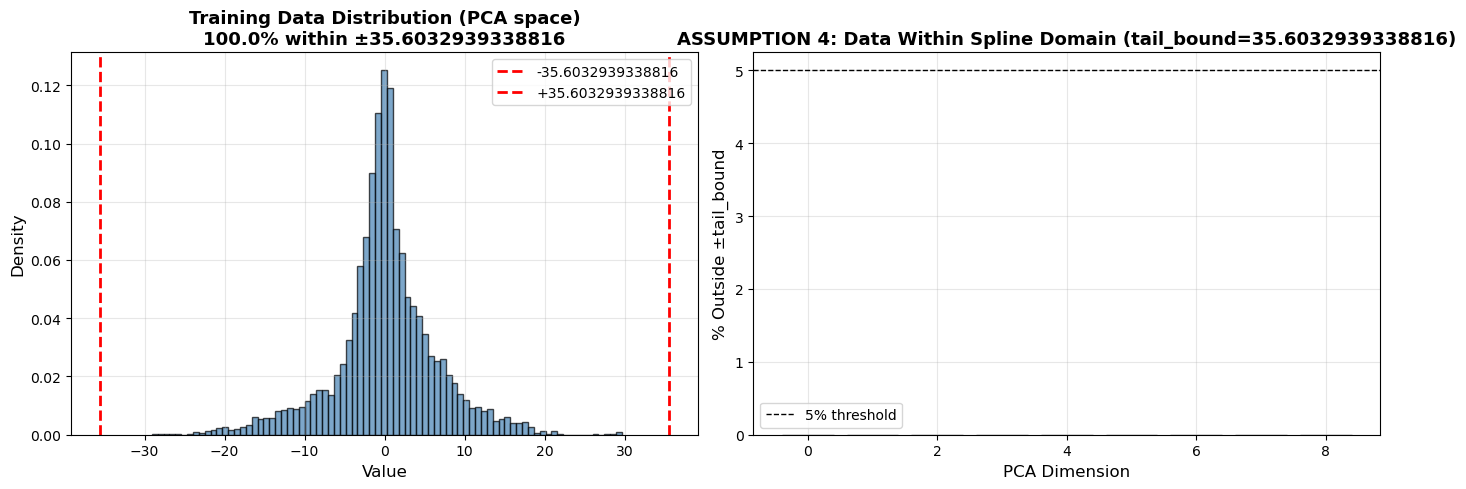


100.0% of all values are within ±35.6032939338816
0/9 dimensions have >5% of values outside the tail bound
✓ Tail bound covers the data well


In [234]:
# =============================================================================
# ASSUMPTION 4: Tail bound covers the data
# Spline acts as identity outside [-tail_bound, tail_bound]. 
# If many values fall outside, the flow can't transform them.
# =============================================================================
tail_bound = TAIL_BOUND  # from config

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) How much training data is within the tail bound (in PCA-reduced space)?
ax = axes[0]
train_vals = normal_reduced[train_idx].flatten()
in_bounds = np.abs(train_vals) <= tail_bound
pct_in = 100 * in_bounds.sum() / len(train_vals)
ax.hist(train_vals, bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(-tail_bound, color='red', linestyle='--', linewidth=2, label=f'-{tail_bound}')
ax.axvline(tail_bound, color='red', linestyle='--', linewidth=2, label=f'+{tail_bound}')
ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Training Data Distribution (PCA space)\n{pct_in:.1f}% within ±{tail_bound}', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# (b) Per-dimension: what fraction falls outside tail bound?
ax = axes[1]
train_data_np = normal_reduced[train_idx]
pct_outside_per_dim = []
for d in range(train_data_np.shape[1]):
    outside = np.abs(train_data_np[:, d]) > tail_bound
    pct_outside_per_dim.append(100 * outside.sum() / len(outside))
colors = ['red' if p > 5 else 'green' for p in pct_outside_per_dim]
ax.bar(range(len(pct_outside_per_dim)), pct_outside_per_dim, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(5, color='black', linestyle='--', linewidth=1, label='5% threshold')
ax.set_xlabel('PCA Dimension', fontsize=12)
ax.set_ylabel('% Outside ±tail_bound', fontsize=12)
ax.set_title(f'ASSUMPTION 4: Data Within Spline Domain (tail_bound={tail_bound})', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

n_bad_dims = sum(1 for p in pct_outside_per_dim if p > 5)
print(f"\n{pct_in:.1f}% of all values are within ±{tail_bound}")
print(f"{n_bad_dims}/{len(pct_outside_per_dim)} dimensions have >5% of values outside the tail bound")
if n_bad_dims > 0:
    print(f"⚠️  Consider increasing tail_bound or re-scaling the data")
else:
    print(f"✓ Tail bound covers the data well")

/var/folders/91/j3k25b391lv5t2z7dsh5s1b00000gn/T/ipykernel_96965/1598727843.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=['Train\n(normal)', 'Test\n(normal)', 'Ambient\n(anomaly)'],


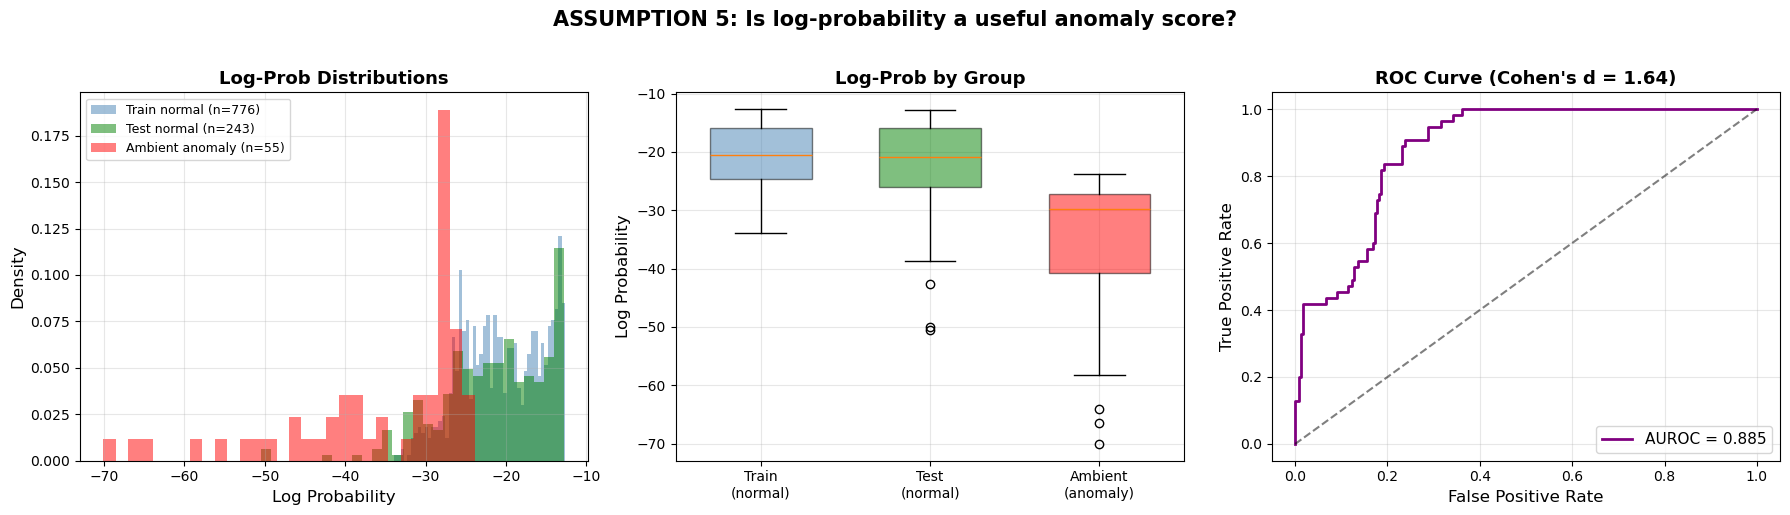


Log-prob statistics:
  Train normal:    mean=-20.48, std=5.05
  Test normal:     mean=-21.79, std=6.79
  Ambient anomaly: mean=-35.58, std=11.47
  Cohen's d (normal vs anomaly): 1.641  (large effect — good separation)
  AUROC: 0.8849  ✓ log-prob is a useful anomaly signal


In [235]:
# =============================================================================
# ASSUMPTION 5: Log-probability is a good anomaly score
# If the flow assigns similar log-probs to normal and anomaly data,
# the density model itself cannot separate them — regardless of threshold.
# =============================================================================
model.eval()
with torch.no_grad():
    # Score all training data
    all_train_lp = model(torch.FloatTensor(normal_reduced[train_idx])).cpu().numpy()
    # Score test normals and anomalies separately
    test_scaled_a5 = scaler.transform(df_test[feature_cols].values)
    test_reduced_a5 = pca.transform(test_scaled_a5)
    polymer_test_lp = model(torch.FloatTensor(test_reduced_a5[:n_polymer_test_diag])).cpu().numpy()
    ambient_lp = model(torch.FloatTensor(test_reduced_a5[n_polymer_test_diag:])).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Overlapping histograms
ax = axes[0]
ax.hist(all_train_lp, bins=50, alpha=0.5, density=True, color='steelblue', label=f'Train normal (n={len(all_train_lp)})')
ax.hist(polymer_test_lp, bins=30, alpha=0.5, density=True, color='green', label=f'Test normal (n={len(polymer_test_lp)})')
ax.hist(ambient_lp, bins=30, alpha=0.5, density=True, color='red', label=f'Ambient anomaly (n={len(ambient_lp)})')
ax.set_xlabel('Log Probability', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Log-Prob Distributions', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# (b) Box plot comparison
ax = axes[1]
data_for_box = [all_train_lp.flatten(), polymer_test_lp.flatten(), ambient_lp.flatten()]
bp = ax.boxplot(data_for_box, labels=['Train\n(normal)', 'Test\n(normal)', 'Ambient\n(anomaly)'],
                patch_artist=True, widths=0.6)
colors_box = ['steelblue', 'green', 'red']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax.set_ylabel('Log Probability', fontsize=12)
ax.set_title('Log-Prob by Group', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# (c) Effect size: Cohen's d between normal and anomaly log-probs
ax = axes[2]
normal_all_lp = np.concatenate([all_train_lp.flatten(), polymer_test_lp.flatten()])
anomaly_all_lp = ambient_lp.flatten()
cohens_d = (normal_all_lp.mean() - anomaly_all_lp.mean()) / np.sqrt(
    (normal_all_lp.std()**2 + anomaly_all_lp.std()**2) / 2
)
# AUROC of log-prob as anomaly score
from sklearn.metrics import roc_auc_score, roc_curve
gt_a5 = np.array([0]*len(polymer_test_lp) + [1]*len(ambient_lp))
scores_a5 = -np.concatenate([polymer_test_lp.flatten(), ambient_lp.flatten()])
auroc_lp = roc_auc_score(gt_a5, scores_a5)
fpr, tpr, _ = roc_curve(gt_a5, scores_a5)
ax.plot(fpr, tpr, color='purple', linewidth=2, label=f'AUROC = {auroc_lp:.3f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f"ROC Curve (Cohen's d = {cohens_d:.2f})", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.suptitle('ASSUMPTION 5: Is log-probability a useful anomaly score?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nLog-prob statistics:")
print(f"  Train normal:    mean={all_train_lp.mean():.2f}, std={all_train_lp.std():.2f}")
print(f"  Test normal:     mean={polymer_test_lp.mean():.2f}, std={polymer_test_lp.std():.2f}")
print(f"  Ambient anomaly: mean={ambient_lp.mean():.2f}, std={ambient_lp.std():.2f}")
print(f"  Cohen's d (normal vs anomaly): {cohens_d:.3f}  ", end="")
if abs(cohens_d) > 0.8:
    print("(large effect — good separation)")
elif abs(cohens_d) > 0.5:
    print("(medium effect — moderate separation)")
elif abs(cohens_d) > 0.2:
    print("(small effect — weak separation)")
else:
    print("(negligible — log-prob cannot distinguish them)")
print(f"  AUROC: {auroc_lp:.4f}  ", end="")
if auroc_lp > 0.75:
    print("✓ log-prob is a useful anomaly signal")
elif auroc_lp > 0.6:
    print("⚠️  log-prob has weak discriminative power")
else:
    print("⚠️  log-prob is NOT discriminative — the fundamental assumption fails")

In [18]:
print(1)


1
